In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
import os

path = os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train')

classes = {'Without_Tumor':0, 'Tumor':1}


In [3]:
import cv2
X = []
Y = []
for cls in classes:
    pth = '/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/'+cls
    for j in os.listdir(pth):
        img = cv2.imread(pth+'/'+j, 0)
        img = cv2.resize(img, (200,200))
        X.append(img)
        Y.append(classes[cls])

In [4]:
X = np.array(X)
Y = np.array(Y)

In [5]:
np.unique(Y)

array([0, 1])

In [6]:
pd.Series(Y).value_counts()

0    1536
1    1451
dtype: int64

In [7]:
X.shape

(2987, 200, 200)

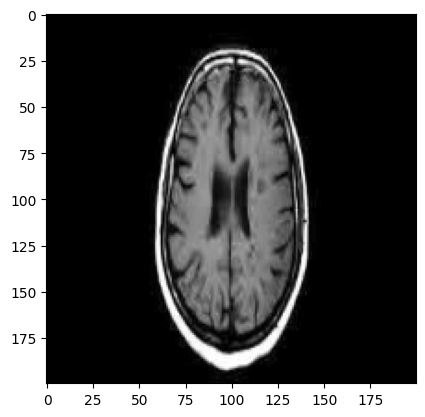

In [8]:
plt.imshow(X[0], cmap='gray')

In [9]:
X_updated = X.reshape(len(X), -1)
X_updated.shape

(2987, 40000)

In [10]:
xtrain, xtest, ytrain, ytest = train_test_split(X_updated, Y, random_state=10,
                                               test_size=.20)

In [11]:
xtrain.shape, xtest.shape

((2389, 40000), (598, 40000))

In [12]:
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())
xtrain = xtrain/255
xtest = xtest/255
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())

255 0
255 0
1.0 0.0
1.0 0.0


In [13]:
from sklearn.decomposition import PCA

In [14]:
print(xtrain.shape, xtest.shape)

pca = PCA(.98)
# pca_train = pca.fit_transform(xtrain)
# pca_test = pca.transform(xtest)
pca_train = xtrain
pca_test = xtest

(2389, 40000) (598, 40000)


In [15]:
from sklearn.neighbors  import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)

In [16]:

import warnings
warnings.filterwarnings('ignore')

lg = knn
lg.fit(pca_train, ytrain)

KNeighborsClassifier(n_neighbors=3)

In [17]:

knn.fit(pca_train, ytrain)

KNeighborsClassifier(n_neighbors=3)

In [18]:
print("Training Score:", lg.score(pca_train, ytrain))
print("Testing Score:", lg.score(pca_test, ytest))

Training Score: 0.9732105483465885
Testing Score: 0.9113712374581939


In [19]:
print("Training Score:", knn.score(pca_train, ytrain))
print("Testing Score:", knn.score(pca_test, ytest))

Training Score: 0.9732105483465885
Testing Score: 0.9113712374581939


In [20]:
dec = {0:'No Tumor', 1:'Positive Tumor'}

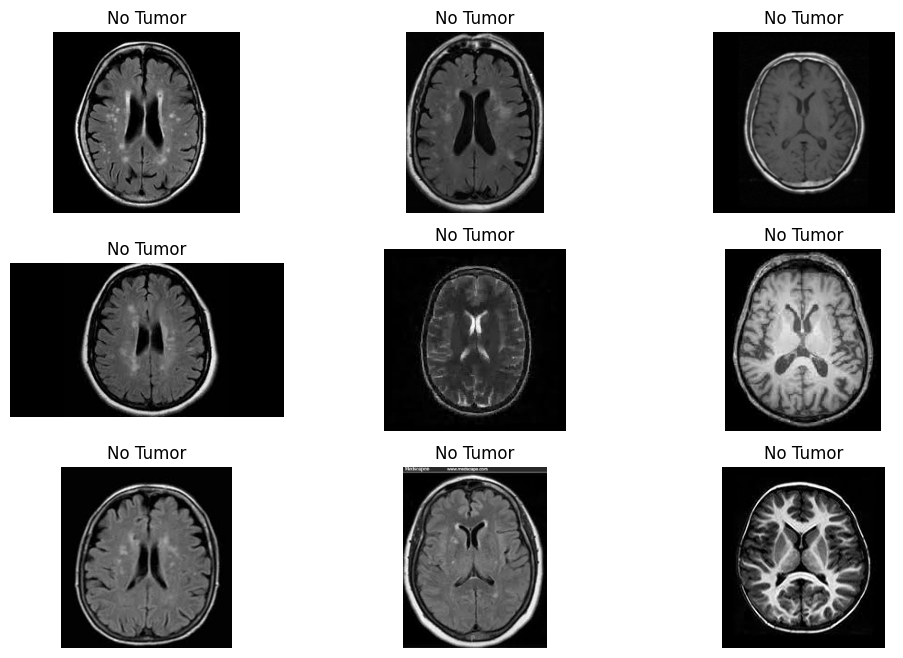

In [23]:
plt.figure(figsize=(12,8))
p = os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test')
c=1
for i in os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/no/')[:9]:
    plt.subplot(3,3,c)

    img = cv2.imread('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/no/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = lg.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

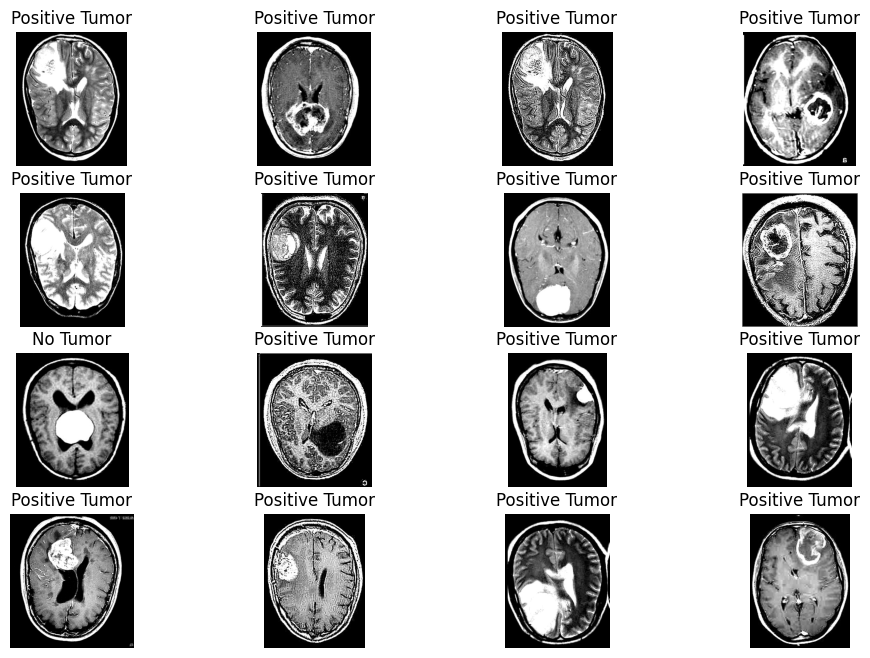

In [25]:
plt.figure(figsize=(12,8))
p = os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test')
c=1
for i in os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/yes/')[:16]:
    plt.subplot(4,4,c)

    img = cv2.imread('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/yes/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = lg.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

In [26]:
y_pred=knn.predict(xtest)

In [27]:
actual=ytest
predicted=y_pred


In [28]:
df={'actuals':actual, 'predictions': predicted}
df=pd.DataFrame(df)
df

,actuals,predictions
0,1,1
1,1,1
2,0,0
3,0,0
4,0,0
...,...,...
593,0,0
594,1,1
595,1,1
596,0,0


In [29]:
cf_matrix = confusion_matrix(df['actuals'] , df['predictions'])
print(cf_matrix)

[[310   7]
 [ 46 235]]


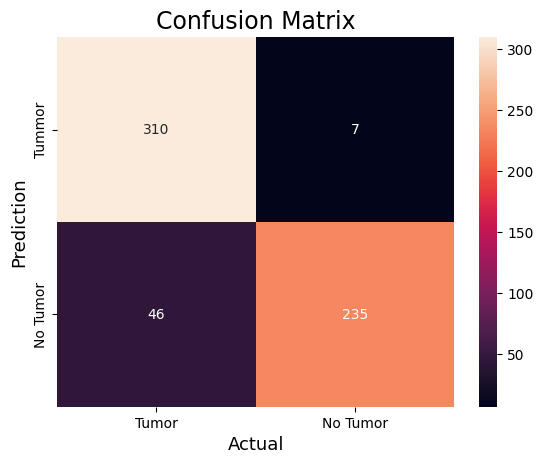

In [30]:
sns.heatmap(cf_matrix,
            annot=True,
            fmt='g',
            xticklabels=['Tumor','No Tumor'],
            yticklabels=['Tummor','No Tumor'])
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

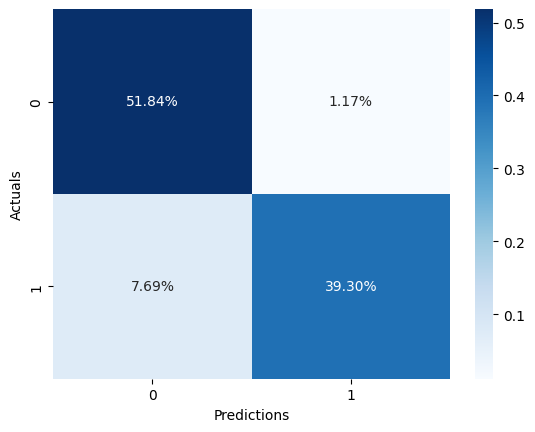

In [31]:
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True,
            fmt='.2%', cmap='Blues')
plt.ylabel('Actuals')
plt.xlabel('Predictions')
plt.show()

In [32]:
True_Negative, True_positive, False_Negative, False_positive= cf_matrix[0][0],cf_matrix[0][1],cf_matrix[1][0],cf_matrix[1][1]
True_Negative, True_positive, False_Negative, False_positive

(310, 7, 46, 235)

In [33]:
from sklearn.metrics import accuracy_score
score =accuracy_score(df['actuals'] , df['predictions'])

score

0.9113712374581939

In [34]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import roc_curve

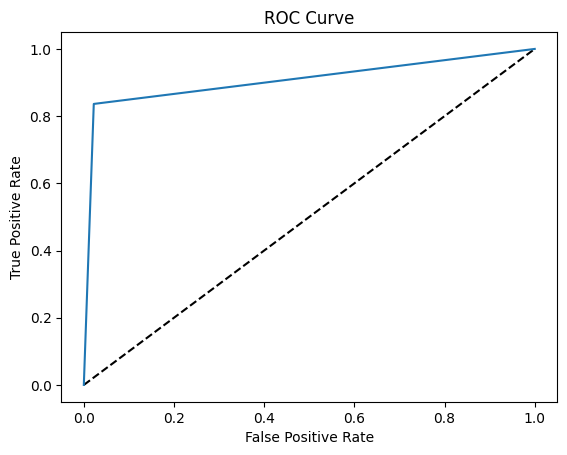

In [35]:
fpr, tpr, thresholds = roc_curve(df['actuals'] , df['predictions'])
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [36]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import roc_curve



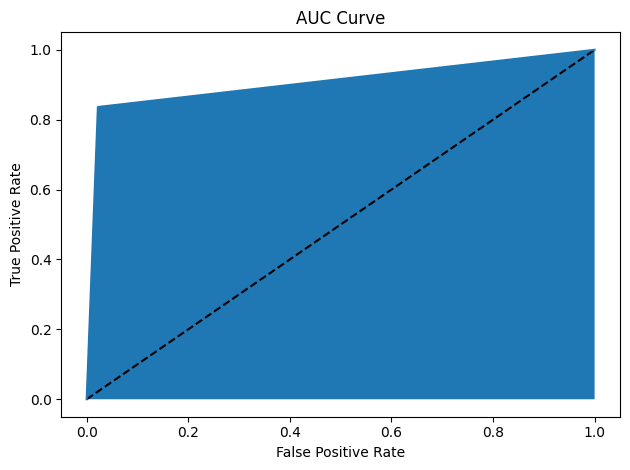

In [37]:
fpr, tpr, thresholds = roc_curve(df['actuals'] , df['predictions'])

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve')

plt.fill_between(fpr, tpr)
plt.tight_layout()
plt.show()

In [38]:
true_labels=ytest
predicted_labels=y_pred

In [39]:
# Finding precision and recall

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


accuracy = accuracy_score(true_labels, predicted_labels)
print("Accuracy   :", accuracy)
precision = precision_score(true_labels, predicted_labels)
print("Precision :", precision)
recall = recall_score(true_labels, predicted_labels)
print("Recall    :", recall)
F1_score = f1_score(true_labels, predicted_labels)
print("F1-score  :", F1_score)

Accuracy   : 0.9113712374581939
Precision : 0.9710743801652892
Recall    : 0.8362989323843416
F1-score  : 0.8986615678776291
